# Repaired FOL signature (`sigfaith`): naming NL→FOL errors and flagging bad gold formulas

This notebook demos **`method.py`** from iteration 2, experiment 5 of a study on **gold-free faithfulness metrics for NL→FOL
translation**. The setting: you have a sentence and a candidate first-order-logic formula, but no gold formula. The metric
should predict whether the formula is faithful to the sentence and, ideally, which kind of error it contains.

**The method (`sigfaith/`).** It compares the *monotonicity signature* of the sentence with the signature of the formula:
* **Text side.** For each content concept in the sentence: does it sit in an upward (+) or downward (−) entailing position
  (restrictor or antecedent vs. nuclear scope or consequent)? Which argument slot does each role word fill?
* **Formula side.** The same properties, computed *exactly* with a SAT solver (z3) over all finite models of size 1..3.
* **Link between the two.** A polarity-blind, renaming-robust **Hungarian aligner** (lemma / WordNet / MiniLM similarity).
* `score = 1 − weighted fraction of mismatching coordinates`. The coordinates are dropped concepts, added predicates,
  polarity flips, swapped slots and relativized mismatches.

Three repairs to the iteration-1 metric were tuned on a screening split and then **frozen**, with a sha256 firewall around
the labels: **R1** a new aligner, **R2** a text-side polarity chooser (`T1c`), and **R3** a rule decoder `D_rule` that maps
the mismatch vector to an error type.

**What `method.py` itself does.** It is the *orchestrator*. It runs 17 resumable pipeline stages as subprocesses (data prep,
screen tuning, freeze, LLM baselines, solver signatures, scoring, analysis, figures, audit). Then its own function
`make_outputs()` joins the frozen scores, the held-out labels and the LLM-judge baselines into `method_out.json`.

**What this demo runs.** The subprocess stages need the full repository, the z3 solver, spaCy, sentence-transformers and API
keys, and they take hours. So the demo loads a **curated subset** of the precomputed per-item records
(`mini_demo_data.json`). It then runs `make_outputs()` **unchanged** on that subset and re-derives the headline validation
numbers on it:
* **V0:** candidate-level AUROC of `S` against B1/TJ LLM judges.
* **V1:** error-type naming.
* **V3:** wrong-gold flagging.

The subset has 100 held-out candidates adjudicated by a 3-LLM panel (50 faithful, 50 unfaithful, spread over 13 error
types), plus the original gold formulas of their 87 sentences.

**Headline result of the full run: all pre-registered verdicts FAIL.** `D_rule` names the error type worse than a typed
Gemini judge (.111 vs .302). Wrong-gold flag AUROC is .673, below the B1/TJ judges (.840 / .859), but the flag *adds* signal
to B1 (.808 → .861).

## 1. Install dependencies
`loguru` (the original script's logger) is not pre-installed on Colab, so it is always installed. numpy, pandas,
scikit-learn and matplotlib are pre-installed on Colab. They are installed here only when running outside Colab, pinned to
Colab's versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## 2. Imports
The first block is the original import block of `method.py`, copied as-is. The second block adds what the demo analysis
and plots need.

In [2]:
from __future__ import annotations

import argparse
import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- additional imports for the notebook's analysis / visualisation cells ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

## 3. Data loading
`mini_demo_data.json` is fetched from the paper's GitHub repo, with a local fallback. It holds every per-item record that
`make_outputs()` reads:

| key | original source file | content |
|---|---|---|
| `inputs` | `data/heldout_inputs.jsonl` (label-free) | sentence, candidate FOL, system, corpus, original gold FOL, complexity |
| `labels` | `data/heldout_labels.jsonl` (behind the firewall) | faithful/unfaithful, panel primary error, sampling weight, gold-audit verdict |
| `heldout_scores` | `results/heldout_scores.jsonl` | frozen `S`, `P`, `A0`, `Ccov`, iteration-1 `A3`, ranked `D_rule` / `D_lr` types, mismatches |
| `gold_scores` | `results/gold_scores.jsonl` | the same measurement applied to each sentence's gold formula (`gold_audit`) |
| `llm_baselines` | `results/llm_baselines.jsonl` | B1 (Gemini-2.5-flash judge) and TJ (typed judge) outputs |
| `frozen_config`, `verdict`, `full_run_reference` | `results/{frozen_config,verdict,analysis}.json` | frozen parameters, pre-registered verdicts, full-run headline numbers |

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data.items() if isinstance(v, list)})

Curated subset of iter-2 experiment 5 (sigfaith): 100 panel3-adjudicated held-out NL->FOL candidates (50 faithful, 50 unfaithful spread over error types) + the original gold formulas of their sentences.
{'inputs': 100, 'labels': 100, 'heldout_scores': 100, 'gold_scores': 87, 'llm_baselines': 374, 'transfer_scores': 0}


## 4. Configuration
These are all the tunable knobs of the demo.
* `N_ITEMS`: how many held-out candidates to push through `make_outputs()` and the analysis. The subset has 100; the full
  run scored all 6,300 heldout_confirm candidates, and 609 of those are panel-adjudicated.
* `N_BOOT`: the number of sentence-clustered bootstrap resamples used for the confidence intervals. `analyze.py` uses 2,000.
* `STAGES_TO_RUN`: the `--stages` argument passed to `main()`. Only `outputs` (`make_outputs()`) can run inside the notebook.
  Every other stage runs a repository script as a subprocess.

In [5]:
N_ITEMS = 100        # candidates used (max 100 in mini_demo_data.json; original full run: 6300, of which 609 panel-labelled)
N_BOOT = 1000        # bootstrap resamples for CIs (original analyze.py: 2000)
SEED = 0
STAGES_TO_RUN = "outputs"   # original default: "all" (needs the full sigfaith repo + z3/spaCy/SBERT + API keys)

data["inputs"] = data["inputs"][:N_ITEMS]
print(f"Using {len(data['inputs'])} candidates")

Using 100 candidates


## 5. Setup: logging and the pipeline stage table (from `method.py`)
In the original script, `ROOT` is the script's own directory. In the notebook it is the working directory, and
`method_out.json` is written there.

`STAGES` is the original ordered pipeline:
* **Screen tuning.** `regress` → `rename2` → `screen_sigs` → `r1_grid` covers repair R1 (aligner grid). `r2_*` covers repair
  R2 (the text-side polarity chooser). `r3` covers repair R3 (the decoder).
* **Freeze.** `freeze` writes `frozen_config.json`, including the sha256 hashes of the code.
* **Held-out phase.** `llm_baselines` (B1, TJ) → `heldout_sigs` (z3 signatures) → `score` → `analyze` → `figures` →
  `audit`.
* **Outputs.** `outputs` calls `make_outputs()` below.

In [6]:
__doc__ = """Naming FOL errors and flagging bad gold — repaired monotonicity-signature metric (iter-2, experiment 5).

METHOD (sigfaith/): the iter-1 Arm-A signature (A3) with three screen-only repairs, then frozen:
  R1 renaming-robust, polarity-blind Hungarian aligner (lemma / WordNet / SBERT + arity term)   -> sigfaith/align2.py
  R2 text-side polarity chooser (rules / gemini probe variants) on MED/HELP-DEV + in-domain silver -> phase1_r2.py
  R3 decoder from the mismatch vector to the panel's error taxonomy (D_rule primary, D_lr secondary)-> sigfaith/decoder.py
BASELINES on identical items: B1 gemini-2.5-flash judge (iter-1 prompt), TJ typed gemini judge, A0 alignment-only,
  Ccov concept coverage, A3_iter1 / A0_iter1 (iter-1 aligner), parse rate, majority-class / prior-random type baselines.
VALIDATION (held-out, labels behind a hash-checked firewall): V1 type naming, V2 blind spots on real errors, V3 wrong-gold
  flagging, V4 polarity increment, criterion 5, V5 document conflation (exploratory), V6 EU-AI-Act transfer.

Pipeline:  python method.py --stages all      (or a comma list of stage names; every stage is resumable/cached)
Outputs:   method_out.json (exp_gen_sol_out) + results/{analysis,verdict,frozen_config,...}.json + figures/
"""

ROOT = Path.cwd()   # original: Path(__file__).resolve().parent
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
PY = sys.executable

STAGES = [
    ("prep", ["prep_data.py"]),
    ("regress", ["phase1_r1.py", "--stage", "regress"]),
    ("rename2", ["phase1_r1.py", "--stage", "rename2"]),
    ("screen_sigs", ["phase1_r1.py", "--stage", "sigs"]),
    ("r1_grid", ["phase1_r1.py", "--stage", "grid"]),
    ("r2_dev", ["phase1_r2.py", "--stage", "dev"]),
    ("r2_pilot", ["phase1_r2.py", "--stage", "pilot"]),
    ("r2_select", ["phase1_r2.py", "--stage", "select"]),
    ("r2_test", ["phase1_r2.py", "--stage", "test"]),
    ("r3", ["phase1_r3.py"]),
    ("freeze", ["freeze.py"]),
    ("llm_baselines", ["phase2_llm.py", "--methods", "B1,TJ"]),
    ("heldout_sigs", ["phase2_sigs.py", "--workers", "3"]),
    ("score", ["phase2_score.py"]),
    ("analyze", ["analyze.py"]),
    ("figures", ["make_figures.py"]),
    ("audit", ["audit_rederive.py"]),
    ("outputs", None),
]
for name, cmd in STAGES:
    print(f"{name:14s} {' '.join(cmd) if cmd else '(in-notebook) make_outputs()'}")

prep           prep_data.py
regress        phase1_r1.py --stage regress
rename2        phase1_r1.py --stage rename2
screen_sigs    phase1_r1.py --stage sigs
r1_grid        phase1_r1.py --stage grid
r2_dev         phase1_r2.py --stage dev
r2_pilot       phase1_r2.py --stage pilot
r2_select      phase1_r2.py --stage select
r2_test        phase1_r2.py --stage test
r3             phase1_r3.py
freeze         freeze.py
llm_baselines  phase2_llm.py --methods B1,TJ
heldout_sigs   phase2_sigs.py --workers 3
score          phase2_score.py
analyze        analyze.py
figures        make_figures.py
audit          audit_rederive.py
outputs        (in-notebook) make_outputs()


### The frozen configuration
These are the parameters `freeze.py` locked before any held-out label was read:
* **Aligner:** `tau` .55, WordNet path similarity, MiniLM-L6 embeddings, arity weight `beta` .1.
* **Text side:** `T1c`.
* **`D_rule` decoder:** per-type evidence weights, plus a prior over the blind-spot types.

In [7]:
fzd = data["frozen_config"]
print("frozen at:", fzd.get("frozen_at_utc"))
print("aligner  :", fzd["aligner"], "->", fzd.get("aligner_name"))
print("text side:", fzd["text_side"])
print("D_rule weights:", fzd["decoder"]["weights"])
print("blind prior   :", fzd["decoder"]["blind_prior"])

frozen at: 2026-09-23T15:30:25Z
aligner  : {'tau': 0.55, 'wn': 'path', 'emb': 'sentence-transformers/all-MiniLM-L6-v2', 'beta': 0.1, 'fallback_mpnet_0.4': False} -> t0.55_path_L6_b0.1
text side: T1c
D_rule weights: {'added_condition': 0.5, 'quantifier_forall_exists': 2.0, 'dropped_condition': 0.5, 'implication_direction_or_only': 2.0, 'negation_polarity': 2.0, 'argument_swap': 1.5, 'conflation': 2.0, 'wrong_split': 1.0, 'connective_and_or': 1.5, 'wrong_constant': 2.0}
blind prior   : ['connective_and_or', 'cardinality_numeric']


## 6. `fmt()` and `make_outputs()` (original code)
`make_outputs()` builds `method_out.json` in the `exp_gen_sol_out` format:
* one example per held-out candidate, with the method's predictions (`predict_S_frozen`, `predict_type_top1`, ...) and the
  baselines' predictions (`predict_B1`, `predict_TJ`, ...);
* one example per held-out gold, for the gold audit (`predict_flag_*` = 1 − score);
* one example per EU-AI-Act transfer formula. This dataset is not included in the demo subset, so that block is empty.

**The only changes are the four data sources.**
* The firewall `heldout_io.load_labels()` and `heldout_io.load_inputs()` are replaced by the `labels` and `inputs` records
  in `data`.
* The JSONL reader `rj(path)` returns the matching list from `data`.
* `analysis.json` is replaced by the stored full-run headline numbers.

Everything else in the function is unchanged.

In [8]:
def fmt(x) -> str:
    if x is None:
        return "NA"
    if isinstance(x, float):
        return f"{x:.6f}"
    return json.dumps(x, ensure_ascii=False) if isinstance(x, (list, dict)) else str(x)


def make_outputs():
    """method_out.json in exp_gen_sol_out format: one example per heldout_confirm row (6,300) with the method's and the
    baselines' predictions, plus one example per held-out gold (gold-audit block) and per transfer formula."""
    # --- notebook data sources (original: sigfaith.heldout_io firewall + results/*.jsonl files) ---
    labels = {r["item_id"]: r for r in data["labels"]}              # original: heldout_io.load_labels()
    inputs = {r["item_id"]: r for r in data["inputs"]}              # original: heldout_io.load_inputs(with_design=False)
    rj = lambda p: data[Path(p).stem]  # noqa: E731                 # original: read the JSONL file at ROOT / p
    sc = {r["unit_id"]: r for r in rj("results/heldout_scores.jsonl")}
    gs = {r["unit_id"]: r for r in rj("results/gold_scores.jsonl")}
    llm = {}
    for r in rj("results/llm_baselines.jsonl"):
        if r.get("error") is None:
            llm[(r["unit_id"], r["method"])] = r
    ex_c = []
    for iid, inp in inputs.items():
        s, lab = sc[iid], labels[iid]
        b1, tj = llm.get((iid, "B1"), {}), llm.get((iid, "TJ"), {})
        ex_c.append({
            "input": json.dumps({"sentence": inp["sentence"], "candidate_fol": inp["candidate_fol"]}, ensure_ascii=False),
            "output": lab["output"],
            "metadata_item_id": iid, "metadata_sentence_id": inp["sentence_id"], "metadata_system": inp["system"],
            "metadata_corpus": inp["corpus"], "metadata_complexity_tercile": inp.get("complexity_tercile"),
            "metadata_label_source": lab.get("label_source"), "metadata_L3_primary_error": lab.get("L3_primary_error"),
            "metadata_L3_sampling_weight": lab.get("L3_sampling_weight"), "metadata_parse_ok_front": s["parse_ok_front"],
            "metadata_covered": s["covered"], "metadata_coverage": s["coverage"], "metadata_why_uncovered": s["why_uncovered"],
            "metadata_mismatches": s["mismatches"][:6], "metadata_seconds": s["seconds"],
            "predict_S_frozen": fmt(s["S_frozen"]), "predict_S_raw": fmt(s["S_raw"]), "predict_P": fmt(s["P_frozen"]),
            "predict_A0": fmt(s["A0_frozen"]), "predict_Ccov": fmt(s["Ccov_frozen"]),
            "predict_A3_iter1": fmt(s["A3_iter1"]), "predict_A0_iter1": fmt(s["A0_iter1"]),
            "predict_type_top1": s["type_top1"], "predict_types_top3": fmt(s["types_rule"][:3]),
            "predict_types_lr_top3": fmt(s["types_lr"][:3]), "predict_legacy_type": fmt(s["legacy_type_panel"]),
            "predict_B1": fmt(b1.get("p_faithful")), "predict_TJ": fmt(tj.get("p_faithful")),
            "predict_TJ_primary": fmt(tj.get("primary")), "predict_TJ_secondary": fmt(tj.get("secondary"))})
    ex_g = []
    seen = set()
    for iid, inp in inputs.items():
        sid = inp["sentence_id"]
        if sid in seen:
            continue
        seen.add(sid)
        g, lab = gs[f"{sid}:gold"], labels[iid]
        b1, tj = llm.get((f"{sid}:gold", "B1"), {}), llm.get((f"{sid}:gold", "TJ"), {})
        ex_g.append({
            "input": json.dumps({"sentence": inp["sentence"], "gold_fol": inp["gold_fol_original"]}, ensure_ascii=False),
            "output": "gold_wrong" if lab.get("gold_faithful_final") is False else
                      ("gold_ok" if lab.get("gold_faithful_final") else "unknown"),
            "metadata_sentence_id": sid, "metadata_corpus": inp["corpus"],
            "metadata_gold_audit_primary_error": lab.get("gold_audit_primary_error"),
            "metadata_paper_corrected_flag": lab.get("paper_corrected_flag"),
            "predict_flag_S": fmt(1 - g["S_frozen"]), "predict_flag_P": fmt(1 - g["P_frozen"]),
            "predict_flag_A0": fmt(1 - g["A0_frozen"]), "predict_flag_A3_iter1": fmt(1 - g["A3_iter1"]),
            "predict_type_top1": g["type_top1"], "predict_types_top3": fmt(g["types_rule"][:3]),
            "predict_flag_B1": fmt(None if b1.get("p_faithful") is None else 1 - b1["p_faithful"]),
            "predict_flag_TJ": fmt(None if tj.get("p_faithful") is None else 1 - tj["p_faithful"]),
            "predict_TJ_primary": fmt(tj.get("primary"))})
    ex_t = []
    for t in rj("results/transfer_scores.jsonl"):
        ex_t.append({"input": json.dumps({"unit_id": t["unit_id"]}), "output": "unlabeled",
                     "metadata_parse_ok_front": t["parse_ok_front"], "metadata_covered": t["covered"],
                     "predict_S_frozen": fmt(t["S_frozen"]), "predict_type_top1": t["type_top1"]})
    A = data["full_run_reference"]   # original: json.loads((ROOT / "results" / "analysis.json").read_text())
    V = data["verdict"]              # original: results/verdict.json
    fz = data["frozen_config"]       # original: results/frozen_config.json
    out = {"metadata": {"method_name": "sigfaith (repaired monotonicity signature: D_rule type namer + gold flagger)",
                        "description": __doc__, "verdict": V, "analysis": A,
                        "frozen_config": {k: v for k, v in fz.items() if k != "tables"},
                        "screen_tables": fz.get("tables"), "api_cost": A.get("api_cost")},
           "datasets": [{"dataset": "heldout_confirm_candidates", "examples": ex_c},
                        {"dataset": "heldout_golds_gold_audit", "examples": ex_g},
                        {"dataset": "transfer_eu_ai_act", "examples": ex_t}]}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False, default=float))
    logger.info(f"method_out.json: {len(ex_c)} candidates, {len(ex_g)} golds, {len(ex_t)} transfer rows")

## 7. `main()`: the stage runner (original code)
The only change is that `parse_args` receives an explicit argument list, because a notebook has no command line.

With `STAGES_TO_RUN = "outputs"`, only the in-process `make_outputs()` runs. With `"all"`, each earlier stage would call its
repository script through `subprocess.run`. Those scripts are not part of this demo.

In [9]:
@logger.catch(reraise=True)
def main(argv=None):
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--stages", default="all")
    a = ap.parse_args(argv)   # original: ap.parse_args() (reads sys.argv)
    names = [s for s, _ in STAGES] if a.stages == "all" else a.stages.split(",")
    for name, cmd in STAGES:
        if name not in names:
            continue
        logger.info(f"=== stage {name}")
        if cmd is None:
            make_outputs()
            continue
        r = subprocess.run([PY, *cmd], cwd=ROOT)
        if r.returncode != 0:
            raise RuntimeError(f"stage {name} failed ({r.returncode})")


main(["--stages", STAGES_TO_RUN])

19:19:33|INFO   |=== stage outputs


19:19:33|INFO   |method_out.json: 100 candidates, 87 golds, 0 transfer rows


## 8. Inspect `method_out.json`
Below is one candidate row. It shows the frozen signature score `S`, the mismatching coordinates behind that score, the
ranked `D_rule` error types, and the judges' outputs, all next to the adjudicated panel label.

In [10]:
MO = json.loads((ROOT / "method_out.json").read_text())
cand = MO["datasets"][0]["examples"]
golds = MO["datasets"][1]["examples"]
ex = next(e for e in cand if e["output"] == "unfaithful" and e["metadata_mismatches"])
print(json.dumps(json.loads(ex["input"]), ensure_ascii=False, indent=1))
print("panel label        :", ex["output"], "| panel primary error:", ex["metadata_L3_primary_error"])
print("S_frozen / A0 / P  :", ex["predict_S_frozen"], ex["predict_A0"], ex["predict_P"])
print("mismatches         :", ex["metadata_mismatches"])
print("D_rule top-3 types :", ex["predict_types_top3"])
print("B1 p(faithful)     :", ex["predict_B1"], "| TJ p(faithful):", ex["predict_TJ"], "| TJ primary:", ex["predict_TJ_primary"])

{
 "sentence": "A person is a dentist if they are trained and licensed to diagnose and treat issues related to teeth and oral health.",
 "candidate_fol": "∀x (Person(x) ∧ TrainedAndLicensed(x) → Dentist(x)) ∧ ∀x (Dentist(x) → (CanDiagnose(x, TeethIssues) ∧ CanTreat(x, OralHealthIssues)))"
}
panel label        : unfaithful | panel primary error: added_condition
S_frozen / A0 / P  : 0.583333 0.833333 0.400000
mismatches         : [{'type': 'label', 'cid': 1, 'pred': 'Dentist', 't': '+', 's': '±'}, {'type': 'label', 'cid': 4, 'pred': 'CanDiagnose', 't': '-', 's': '+'}, {'type': 'label', 'cid': 5, 'pred': 'CanTreat', 't': '-', 's': '+'}, {'type': 'dropped', 'cid': 7, 't': '-'}, {'type': 'dropped', 'cid': 8, 't': '-'}]
D_rule top-3 types : ["quantifier_forall_exists", "conflation", "dropped_condition"]
B1 p(faithful)     : 0.050000 | TJ p(faithful): 0.200000 | TJ primary: implication_direction_or_only


## 9. Demo re-analysis of the headline validations
This is a compact version of `analyze.py`, run on the demo subset.
* Items are weighted by `L3_sampling_weight`, the panel's stratified design weight.
* CIs are **sentence-clustered** percentile bootstraps.
* Missing scores are filled with 0.5, as in the original.

The three validations:
* **V0 (standalone)**: AUROC of each score for *faithful vs. unfaithful* candidates.
* **V1 (type naming)**: on unfaithful candidates, weighted top-1 accuracy of the `D_rule` type against the panel's primary
  error. It is compared with the TJ judge's primary type and with the majority-class baseline (`added_condition`).
* **V3 (wrong-gold flag)**: AUROC of `1 − score` for *gold_wrong vs. gold_ok* on the sentences' original gold formulas.

With only 100 items the CIs are wide. The full-run values (n = 609 panel items, 700 golds) are shown beside the demo values.

**How to read the demo numbers.** The unfaithful half of the subset was sampled *evenly across error types* (about 4 per
type), not in the panel's natural mix. As a result:
* the majority-class baseline is much weaker here than in the full run;
* per-type hit rates weigh rare types as heavily as common ones.

Treat the demo values as illustrations, and use the full-run column as the reported result.

In [11]:
def num(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return 0.5   # analyze.py fills missing scores with 0.5 (n_missing_filled_0.5)

def boot_auc(y, s, w, groups, n_boot=N_BOOT, seed=SEED):
    y, s, w, groups = map(np.asarray, (y, s, w, groups))
    point = roc_auc_score(y, s, sample_weight=w)
    rng = np.random.default_rng(seed)
    ug = np.unique(groups)
    idx_by_g = {g: np.where(groups == g)[0] for g in ug}
    bs = []
    for _ in range(n_boot):
        idx = np.concatenate([idx_by_g[g] for g in rng.choice(ug, len(ug), replace=True)])
        if len(set(y[idx])) < 2:
            continue
        bs.append(roc_auc_score(y[idx], s[idx], sample_weight=w[idx]))
    return point, np.percentile(bs, 2.5), np.percentile(bs, 97.5)

ref = data["full_run_reference"]

# ---- V0 standalone: candidate faithfulness AUROC ----
y = [1 if e["output"] == "faithful" else 0 for e in cand]
w = [float(e["metadata_L3_sampling_weight"] or 1.0) for e in cand]
g = [e["metadata_sentence_id"] for e in cand]
V0_METRICS = {"S": "predict_S_frozen", "P": "predict_P", "A0": "predict_A0", "Ccov": "predict_Ccov",
              "A3i": "predict_A3_iter1", "B1": "predict_B1", "TJ": "predict_TJ"}
v0 = []
for m, key in V0_METRICS.items():
    pt, lo, hi = boot_auc(y, [num(e[key]) for e in cand], w, g)
    v0.append({"metric": m, "demo_auroc_w": pt, "ci_lo": lo, "ci_hi": hi, "full_run_auroc_w": ref["standalone_auroc_w"].get(m)})
v0 = pd.DataFrame(v0)
print(f"V0 standalone AUROC (n={len(cand)}, faithful={sum(y)})")
print(v0.round(3).to_string(index=False))

# ---- V1 type naming on unfaithful candidates ----
U = [e for e in cand if e["output"] == "unfaithful" and e["metadata_L3_primary_error"]]
wU = np.array([float(e["metadata_L3_sampling_weight"] or 1.0) for e in U])
truth = [e["metadata_L3_primary_error"] for e in U]
preds = {"D_rule": [e["predict_type_top1"] for e in U],
         "D_lr": [json.loads(e["predict_types_lr_top3"])[0] for e in U],
         "TJ": [e["predict_TJ_primary"] for e in U],
         "majority_added": ["added_condition"] * len(U)}
v1 = pd.DataFrame([{"method": k, "demo_top1_w": float(np.sum(wU * (np.array(p) == np.array(truth))) / wU.sum()),
                    "full_run_top1_w": ref["V1_top1_w"].get(k)} for k, p in preds.items()])
print(f"\nV1 type naming, top-1 accuracy (n_unfaithful={len(U)})")
print(v1.round(3).to_string(index=False))

# ---- V3 wrong-gold flagging ----
GL = [e for e in golds if e["output"] in ("gold_wrong", "gold_ok")]
yg = [1 if e["output"] == "gold_wrong" else 0 for e in GL]
gg = [e["metadata_sentence_id"] for e in GL]
V3_METRICS = {"flag_S": "predict_flag_S", "flag_A0": "predict_flag_A0", "flag_P": "predict_flag_P",
              "flag_A3iter1": "predict_flag_A3_iter1", "flag_B1": "predict_flag_B1", "flag_TJ": "predict_flag_TJ"}
v3 = []
for m, key in V3_METRICS.items():
    pt, lo, hi = boot_auc(yg, [num(e[key]) for e in GL], [1.0] * len(GL), gg)
    v3.append({"flag": m, "demo_auroc": pt, "ci_lo": lo, "ci_hi": hi, "full_run_auroc": ref["V3_pooled_auroc"].get(m)})
v3 = pd.DataFrame(v3)
print(f"\nV3 wrong-gold flag AUROC (n_golds={len(GL)}, wrong={sum(yg)})")
print(v3.round(3).to_string(index=False))

V0 standalone AUROC (n=100, faithful=50)
metric  demo_auroc_w  ci_lo  ci_hi  full_run_auroc_w
     S         0.534  0.394  0.666             0.654
     P         0.391  0.277  0.519             0.580
    A0         0.722  0.609  0.830             0.673
  Ccov         0.702  0.585  0.811             0.674
   A3i         0.543  0.402  0.677             0.639
    B1         0.733  0.609  0.841             0.745
    TJ         0.750  0.637  0.854             0.777

V1 type naming, top-1 accuracy (n_unfaithful=50)
        method  demo_top1_w  full_run_top1_w
        D_rule        0.075            0.111
          D_lr        0.112            0.145
            TJ        0.273            0.302
majority_added        0.092            0.249



V3 wrong-gold flag AUROC (n_golds=87, wrong=46)
        flag  demo_auroc  ci_lo  ci_hi  full_run_auroc
      flag_S       0.731  0.624  0.835           0.673
     flag_A0       0.664  0.557  0.770           0.690
      flag_P       0.634  0.521  0.732           0.547
flag_A3iter1       0.637  0.509  0.757           0.626
     flag_B1       0.810  0.710  0.893           0.840
     flag_TJ       0.856  0.768  0.923           0.859


## 10. Results summary and visualisation
The table and plots below show:
* the full-run pre-registered verdicts, all FAIL;
* the demo-subset estimates next to the full-run numbers;
* per error type, how often the `D_rule` type namer is right.

Pre-registered verdicts (full held-out run):
  DIAGNOSER_POSITIVE         pass=False  {'D_rule_top1_w': 0.111, 'TJ_top1_w': 0.302}
  FLAGGER_POSITIVE           pass=False  {'pooled_auroc': 0.673, 'B1_auroc': 0.84, 'TJ_auroc': 0.859}
  POLARITY_CARRIES_SIGNAL    pass=False  {'delta_M2_M0': 0.011}
  RENAME_FIXED               pass=False  {'FA_rename_test': 0.129, 'criterion5_full_match': 0.256}
  BLIND_SPOTS_CONFIRMED      pass=False  {'visible_det': 0.727, 'blind_det': 0.591}

Coverage/cost (full run): parse_ok 0.952, covered 0.938, median 0.061 s/item, signature $0/item vs TJ $0.00022/item; total API $4.48


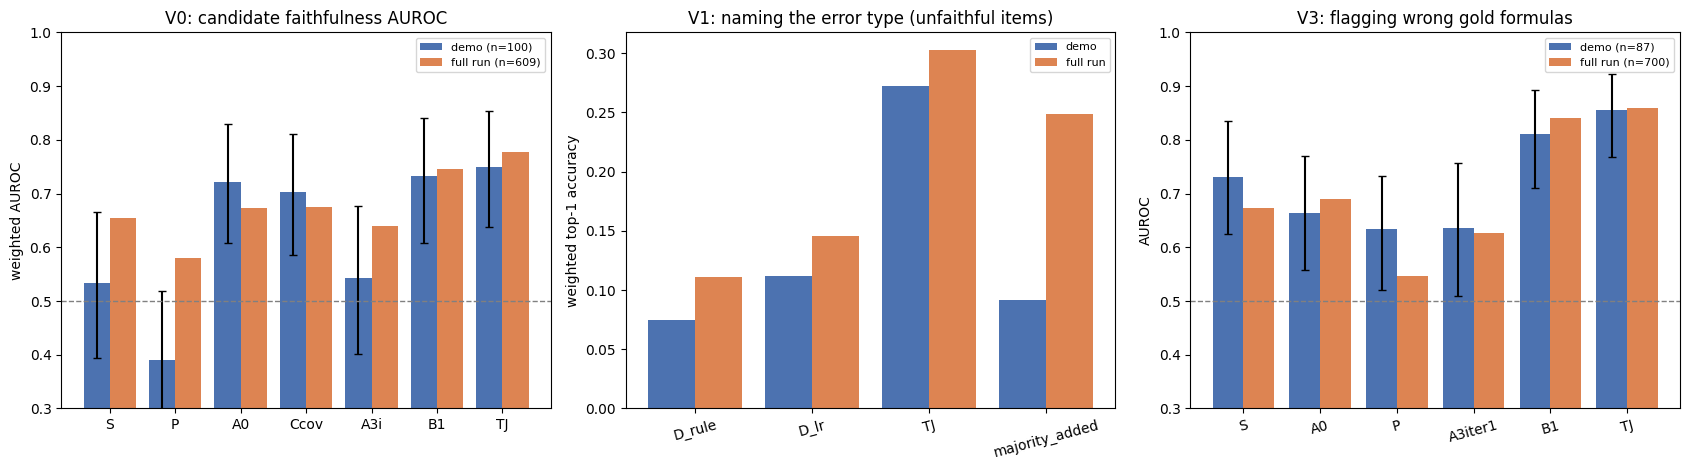


Per panel-primary-error type (demo subset, unweighted hit rate):
                               n  D_rule_hit  TJ_hit
truth                                               
added_condition                5        0.20    0.00
argument_swap                  4        0.00    0.25
cardinality_numeric            1        0.00    0.00
conflation                     4        0.00    0.00
connective_and_or              4        0.00    1.00
dropped_condition              4        0.50    0.25
implication_direction_or_only  4        0.00    0.25
negation_polarity              4        0.00    0.50
quantifier_forall_exists       4        0.25    1.00
quantifier_scope               4        0.00    0.00
syntax_unparseable             4        0.00    0.00
wrong_constant                 4        0.00    0.00
wrong_split                    4        0.00    0.00


In [12]:
print("Pre-registered verdicts (full held-out run):")
for k, v in data["verdict"].items():
    extra = {kk: (round(vv, 3) if isinstance(vv, float) else vv) for kk, vv in v.items()
             if kk in ("D_rule_top1_w", "TJ_top1_w", "pooled_auroc", "B1_auroc", "TJ_auroc", "delta_M2_M0",
                       "FA_rename_test", "criterion5_full_match", "visible_det", "blind_det")}
    print(f"  {k:26s} pass={v['pass']}  {extra}")
cc = ref["coverage_cost"]
print(f"\nCoverage/cost (full run): parse_ok {cc['parse_ok_rate']:.3f}, covered {cc['covered_rate']:.3f}, "
      f"median {cc['sec_per_item_median']} s/item, signature $0/item vs TJ ${cc['usd_per_item_TJ']:.5f}/item; "
      f"total API ${ref['api_cost']['total_usd']:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
# (a) V0 standalone AUROC
xs = np.arange(len(v0))
ax[0].bar(xs - 0.2, v0.demo_auroc_w, 0.4, yerr=[v0.demo_auroc_w - v0.ci_lo, v0.ci_hi - v0.demo_auroc_w],
          capsize=3, label=f"demo (n={len(cand)})", color="#4C72B0")
ax[0].bar(xs + 0.2, v0.full_run_auroc_w, 0.4, label=f"full run (n={ref['n_panel']})", color="#DD8452")
ax[0].axhline(0.5, ls="--", c="grey", lw=1)
ax[0].set_xticks(xs, v0.metric); ax[0].set_ylim(0.3, 1.0); ax[0].set_ylabel("weighted AUROC")
ax[0].set_title("V0: candidate faithfulness AUROC"); ax[0].legend(fontsize=8)
# (b) V1 type naming
xs = np.arange(len(v1))
ax[1].bar(xs - 0.2, v1.demo_top1_w, 0.4, label="demo", color="#4C72B0")
ax[1].bar(xs + 0.2, v1.full_run_top1_w, 0.4, label="full run", color="#DD8452")
ax[1].set_xticks(xs, v1.method, rotation=15); ax[1].set_ylabel("weighted top-1 accuracy")
ax[1].set_title("V1: naming the error type (unfaithful items)"); ax[1].legend(fontsize=8)
# (c) V3 wrong-gold flag
xs = np.arange(len(v3))
ax[2].bar(xs - 0.2, v3.demo_auroc, 0.4, yerr=[v3.demo_auroc - v3.ci_lo, v3.ci_hi - v3.demo_auroc],
          capsize=3, label=f"demo (n={len(GL)})", color="#4C72B0")
ax[2].bar(xs + 0.2, v3.full_run_auroc, 0.4, label="full run (n=700)", color="#DD8452")
ax[2].axhline(0.5, ls="--", c="grey", lw=1)
ax[2].set_xticks(xs, [m.replace("flag_", "") for m in v3.flag], rotation=15); ax[2].set_ylim(0.3, 1.0)
ax[2].set_ylabel("AUROC"); ax[2].set_title("V3: flagging wrong gold formulas"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# per-type: does D_rule / TJ name the panel's primary error?
pt = pd.DataFrame({"truth": truth, "D_rule": np.array(preds["D_rule"]) == np.array(truth),
                   "TJ": np.array(preds["TJ"]) == np.array(truth)})
per_type = pt.groupby("truth").agg(n=("D_rule", "size"), D_rule_hit=("D_rule", "mean"), TJ_hit=("TJ", "mean"))
print("\nPer panel-primary-error type (demo subset, unweighted hit rate):")
print(per_type.round(2).to_string())